# Aplicação de Multi-layer Perceptron à séries temporais variantes no tempo

Dataset

Qual o objetivo?

Quais são as técnicas para separação dos dados? (Validação cruzada)

Quais os possíveis problemas no treinamento;

Na arquitetura do Modelo, qual a técnica ultizada para a escolha dos hiperparâmetros.

Quais as métricas de validação usadas para avaliar o desempenho do modelo.

## Carregando o _Dataset_

In [21]:
import json
import optuna
import random
from datetime import datetime

import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pystac_client
import requests
import seaborn
from scipy.signal import savgol_filter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from kfold import Kfold
from mlp_multiclass import FFNeuralNetwork, He_, Layer, Neuron, Xavier
from temporal_classification import (classify_temporal_series,
                                     plot_real_trajectory,
                                     plot_temporal_classification)

from optuna.visualization.matplotlib import (
    plot_optimization_history,
    plot_param_importances
)

def get_ts(sample):
    ts_ = json.loads(sample['time_series'])
    return pd.DataFrame(ts_)

def plot_ts(data_df, selected_line, marker=True, smoothed=False, step=5):
    ts = pd.DataFrame(json.loads(data_df['time_series'][selected_line]))
    fig = plt.figure(figsize=(10, 4))
    smoothed_ = ' Smoothed' if smoothed else ''
    fig.suptitle(
        ("{cube} {label} [{lng:,.4f}, {lat:,.4f}]{smoothed_} WGS 84 EPSG:4326").format(
            cube=data_df['cube'][selected_line],
            label=data_df['label'][selected_line],
            lng=data_df['longitude'][selected_line],
            lat=data_df['latitude'][selected_line],
            smoothed_=smoothed_
        )
    )
    seaborn.set_theme(style="darkgrid")
    bands = [band for band in list(ts.keys()) if band != 'Index']
    marker_ = 'o' if marker else None
    for band in bands:
        seaborn.lineplot(
            data=ts,
            x="Index",
            y=band,
            label=band,
            markersize=8,
            marker=marker_,
            linestyle='-'
        )
    ax = plt.gca()
    xticks = range(0, len(ts["Index"]), step)
    ax.set_xticks(xticks)
    ax.set_xticklabels(
        ts["Index"].iloc[::step]
    )
    plt.xlabel(None)
    plt.ylabel(None)
    plt.legend()
    plt.tight_layout()
    plt.show()

# get bands description
service = pystac_client.Client.open("https://data.inpe.br/bdc/stac/v1/")
collection = service.get_collection('mod13q1-6.1').to_dict()
bands_description = collection['properties']['eo:bands']

# Recuperando a base de dados
samples = pd.read_csv('./samples/samples_mt_time_series.csv')

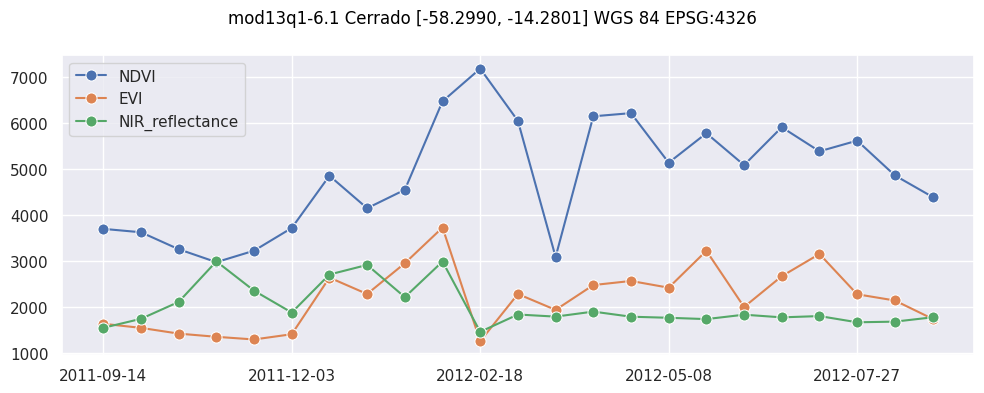

In [3]:
plot_ts(samples, random.randint(0, (len(samples) - 1)))

## Selecionando os atributos

In [4]:
def extract_bands_ts(samples, line, bands_to_select):
    ts_ = pd.DataFrame(json.loads(samples['time_series'][line]))
    bands_ = ["Index"] + bands_to_select
    ts_ = ts_[bands_]
    return ts_

def extract_bands(samples, bands):
    samples_ = samples.copy()
    for row in range(0, len(samples_)):
        samples_.loc[row, 'time_series'] = json.dumps(extract_bands_ts(samples_, row, bands).to_dict(orient="list"))
    return samples_

bands = ["NDVI", "EVI", "NIR_reflectance"]
samples = extract_bands(samples, bands)

## Normalização dos valores referente ao satélite

In [5]:
def get_band_description(band, bands_description):
    selected = {}
    for band_desc in bands_description:
        if band_desc['name'] == band:
            selected = band_desc
            break
    return selected
    
def normalize_ts(samples, line, bands_description):
    ts_ = pd.DataFrame(json.loads(samples['time_series'][line]))
    for column in ts_.columns:
        if column != "Index":
            band_desc = get_band_description(column, bands_description)
            scale = band_desc['scale']
            ts_[column] = ts_[column] * scale
    return ts_

def normalize_(samples, bands_description):
    samples_ = samples.copy()
    for row in range(0, len(samples_)):
        samples_.loc[row, 'time_series'] = json.dumps(normalize_ts(samples_, row, bands_description).to_dict(orient="list"))
    return samples_

samples_norm = normalize_(samples, bands_description)
samples_norm

,longitude,latitude,label,start_date,end_date,cube,time_series
0,-55.9643,-10.0621,Pasture,2005-09-14,2006-08-29,mod13q1-6.1,"{""Index"": [""2005-09-14"", ""2005-09-30"", ""2005-1..."
1,-54.5540,-10.3749,Pasture,2013-09-14,2014-08-29,mod13q1-6.1,"{""Index"": [""2013-09-14"", ""2013-09-30"", ""2013-1..."
2,-52.4572,-10.9512,Pasture,2013-09-14,2014-08-29,mod13q1-6.1,"{""Index"": [""2013-09-14"", ""2013-09-30"", ""2013-1..."
3,-52.1443,-13.9981,Pasture,2013-09-14,2014-08-29,mod13q1-6.1,"{""Index"": [""2013-09-14"", ""2013-09-30"", ""2013-1..."
4,-57.6907,-13.3382,Pasture,2015-09-14,2016-08-28,mod13q1-6.1,"{""Index"": [""2015-09-14"", ""2015-09-30"", ""2015-1..."
...,...,...,...,...,...,...,...
2110,-57.9273,-13.4216,Soy-Fallow,2006-09-14,2007-08-29,mod13q1-6.1,"{""Index"": [""2006-09-14"", ""2006-09-30"", ""2006-1..."
2111,-57.9254,-13.4254,Soy-Fallow,2006-09-14,2007-08-29,mod13q1-6.1,"{""Index"": [""2006-09-14"", ""2006-09-30"", ""2006-1..."
2112,-57.9254,-13.4235,Soy-Fallow,2006-09-14,2007-08-29,mod13q1-6.1,"{""Index"": [""2006-09-14"", ""2006-09-30"", ""2006-1..."
2113,-57.9254,-13.4216,Soy-Fallow,2006-09-14,2007-08-29,mod13q1-6.1,"{""Index"": [""2006-09-14"", ""2006-09-30"", ""2006-1..."


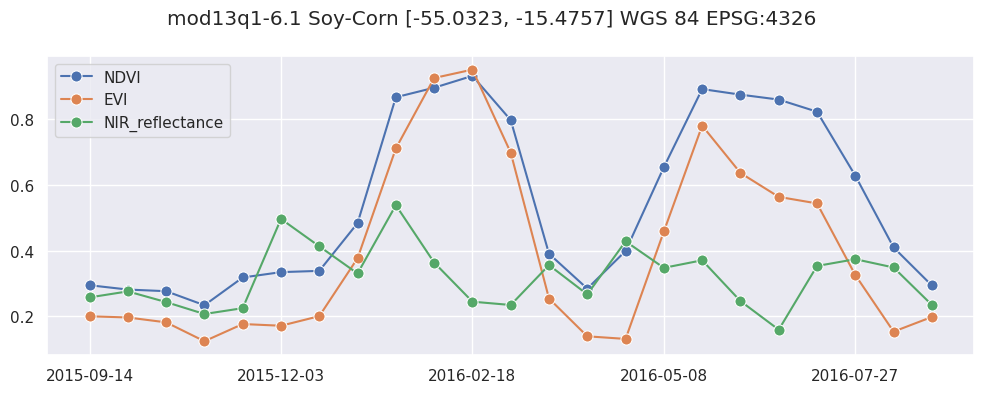

In [6]:
plot_ts(samples_norm, random.randint(0, (len(samples_norm) - 1)))

## Interpolação de valores nulos referente ao satélite

In [7]:
missing_value = 0

def _set_NaN(value):
    if value != missing_value:
        return value
    else:
        return None

def interpolate_ts(samples, line, bands_description):
    ts_ = pd.DataFrame(json.loads(samples['time_series'][line]))
    for column in ts_.columns:
        if column != "Index":
            band_desc = get_band_description(column, bands_description)
            scale = band_desc['scale']
            missing_value = band_desc['nodata'] * scale
            ts_[column] = ts_[column].apply(_set_NaN).interpolate(
                method = 'linear',
                limit_direction = 'forward',
                order = 2
            )
    return ts_

def interpolate_(samples, bands_description):
    samples_ = samples.copy()
    for row in range(0, len(samples_)):
        samples_.loc[row, 'time_series'] = json.dumps(interpolate_ts(samples_, row, bands_description).to_dict(orient="list"))
    return samples_

samples_inter = interpolate_(samples_norm, bands_description)
samples_inter

,longitude,latitude,label,start_date,end_date,cube,time_series
0,-55.9643,-10.0621,Pasture,2005-09-14,2006-08-29,mod13q1-6.1,"{""Index"": [""2005-09-14"", ""2005-09-30"", ""2005-1..."
1,-54.5540,-10.3749,Pasture,2013-09-14,2014-08-29,mod13q1-6.1,"{""Index"": [""2013-09-14"", ""2013-09-30"", ""2013-1..."
2,-52.4572,-10.9512,Pasture,2013-09-14,2014-08-29,mod13q1-6.1,"{""Index"": [""2013-09-14"", ""2013-09-30"", ""2013-1..."
3,-52.1443,-13.9981,Pasture,2013-09-14,2014-08-29,mod13q1-6.1,"{""Index"": [""2013-09-14"", ""2013-09-30"", ""2013-1..."
4,-57.6907,-13.3382,Pasture,2015-09-14,2016-08-28,mod13q1-6.1,"{""Index"": [""2015-09-14"", ""2015-09-30"", ""2015-1..."
...,...,...,...,...,...,...,...
2110,-57.9273,-13.4216,Soy-Fallow,2006-09-14,2007-08-29,mod13q1-6.1,"{""Index"": [""2006-09-14"", ""2006-09-30"", ""2006-1..."
2111,-57.9254,-13.4254,Soy-Fallow,2006-09-14,2007-08-29,mod13q1-6.1,"{""Index"": [""2006-09-14"", ""2006-09-30"", ""2006-1..."
2112,-57.9254,-13.4235,Soy-Fallow,2006-09-14,2007-08-29,mod13q1-6.1,"{""Index"": [""2006-09-14"", ""2006-09-30"", ""2006-1..."
2113,-57.9254,-13.4216,Soy-Fallow,2006-09-14,2007-08-29,mod13q1-6.1,"{""Index"": [""2006-09-14"", ""2006-09-30"", ""2006-1..."


## Suavização Savitzky Golay para generalizar as features

In [8]:
class SGolay:
    def __init__(self, window_size: int, polynomial_order: int, mode: str = "interp"):
        self.mode = mode
        if (window_size % 2) != 0:
            self.window_size = window_size
        else:
            raise Exception("Window size must be odd number!")
        if window_size > polynomial_order:
            self.polynomial_order = polynomial_order
        else:
            raise Exception("Window size must be higher than the polynomial order!")

    def apply(self, samples, line):
        ts_ = pd.DataFrame(json.loads(samples['time_series'][line]))
        return self.apply_ts(ts_)

    def apply_ts(self, ts_):
        for column in ts_.columns:
            if column != "Index":
                ts_[column] = savgol_filter(
                    ts_[column],
                    window_length=self.window_size,
                    polyorder=self.polynomial_order,
                    mode=self.mode
                )
        return ts_

def smooth_(samples):
    samples_ = samples.copy()
    for row in range(0, len(samples_)):
        samples_.loc[row, 'time_series'] = json.dumps(sgolay.apply(samples_, row).to_dict(orient="list"))
    return samples_


sgolay = SGolay(7, 3)

samples_smoothed = smooth_(samples_inter)
samples_smoothed

,longitude,latitude,label,start_date,end_date,cube,time_series
0,-55.9643,-10.0621,Pasture,2005-09-14,2006-08-29,mod13q1-6.1,"{""Index"": [""2005-09-14"", ""2005-09-30"", ""2005-1..."
1,-54.5540,-10.3749,Pasture,2013-09-14,2014-08-29,mod13q1-6.1,"{""Index"": [""2013-09-14"", ""2013-09-30"", ""2013-1..."
2,-52.4572,-10.9512,Pasture,2013-09-14,2014-08-29,mod13q1-6.1,"{""Index"": [""2013-09-14"", ""2013-09-30"", ""2013-1..."
3,-52.1443,-13.9981,Pasture,2013-09-14,2014-08-29,mod13q1-6.1,"{""Index"": [""2013-09-14"", ""2013-09-30"", ""2013-1..."
4,-57.6907,-13.3382,Pasture,2015-09-14,2016-08-28,mod13q1-6.1,"{""Index"": [""2015-09-14"", ""2015-09-30"", ""2015-1..."
...,...,...,...,...,...,...,...
2110,-57.9273,-13.4216,Soy-Fallow,2006-09-14,2007-08-29,mod13q1-6.1,"{""Index"": [""2006-09-14"", ""2006-09-30"", ""2006-1..."
2111,-57.9254,-13.4254,Soy-Fallow,2006-09-14,2007-08-29,mod13q1-6.1,"{""Index"": [""2006-09-14"", ""2006-09-30"", ""2006-1..."
2112,-57.9254,-13.4235,Soy-Fallow,2006-09-14,2007-08-29,mod13q1-6.1,"{""Index"": [""2006-09-14"", ""2006-09-30"", ""2006-1..."
2113,-57.9254,-13.4216,Soy-Fallow,2006-09-14,2007-08-29,mod13q1-6.1,"{""Index"": [""2006-09-14"", ""2006-09-30"", ""2006-1..."


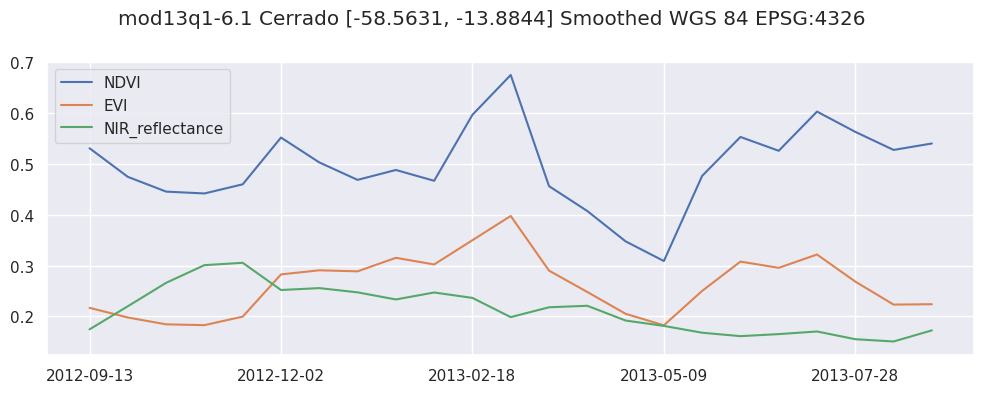

In [9]:
plot_ts(samples_smoothed, random.randint(0, (len(samples_inter) - 1)), marker = False, smoothed=True)

## Verificação simples para ver que as séries estão com os mesmo número de time stamps

In [10]:
def count_ts(samples):
    samples_ = samples.copy()
    count = []
    for row in range(0, len(samples_)):
        count.append(len(json.loads(samples_['time_series'][0])['Index']))
    return count

set(count_ts(samples_smoothed))

{23}

## Análise Exploratória

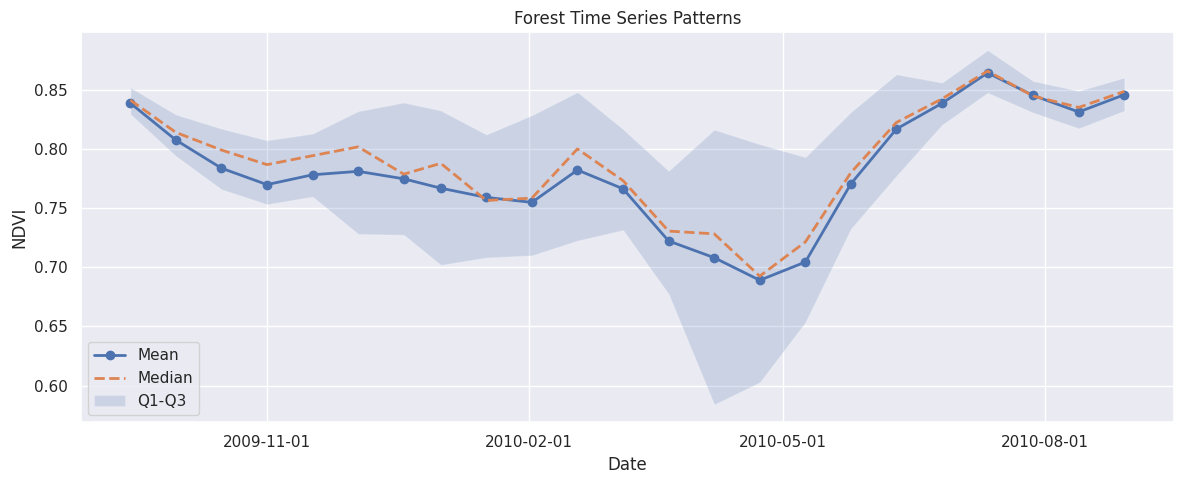

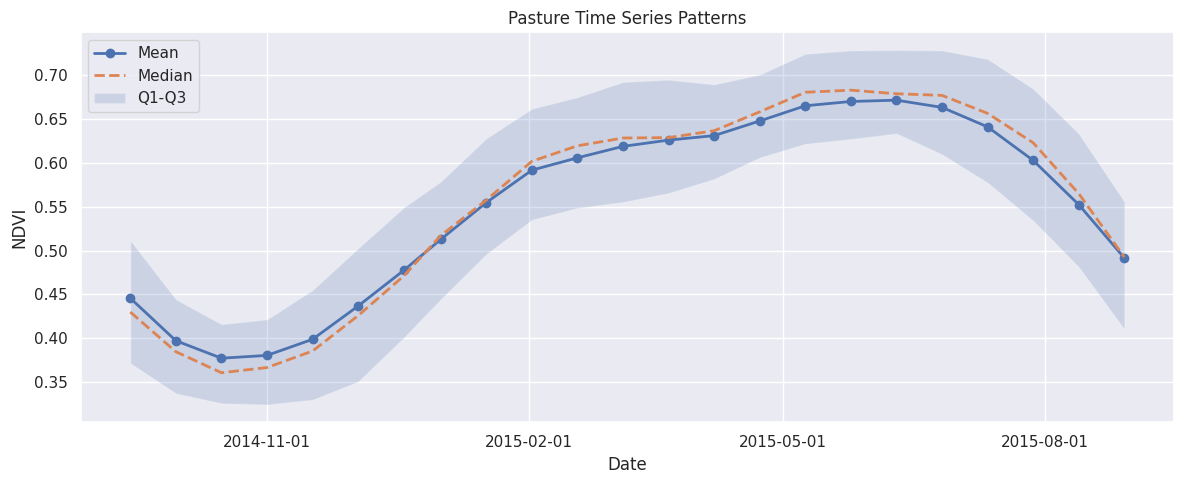

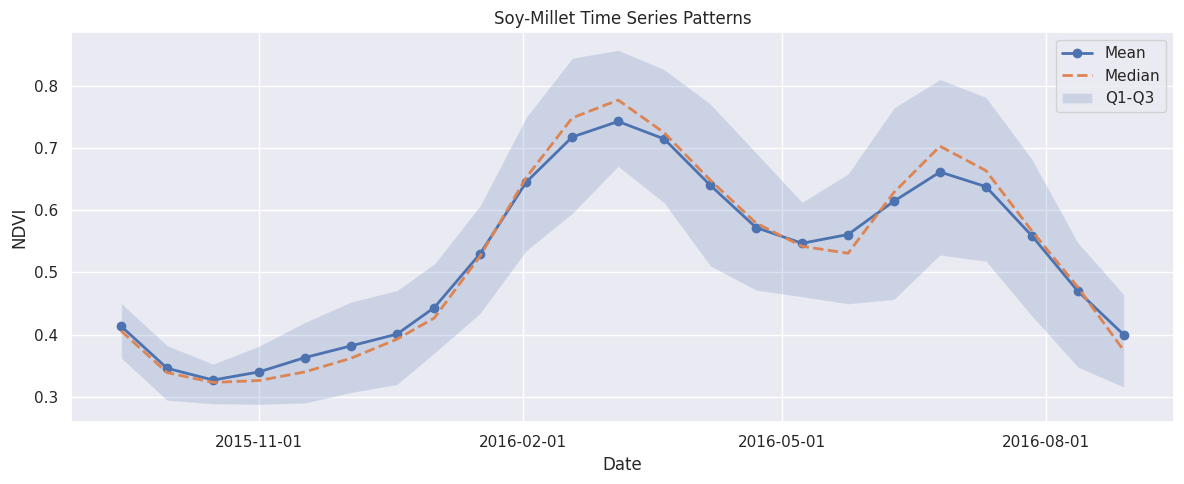

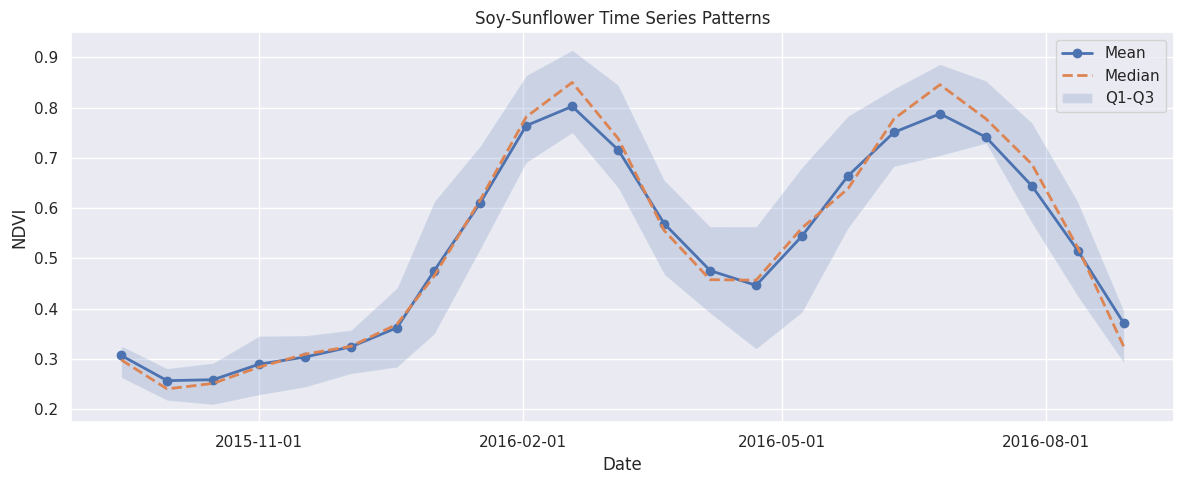

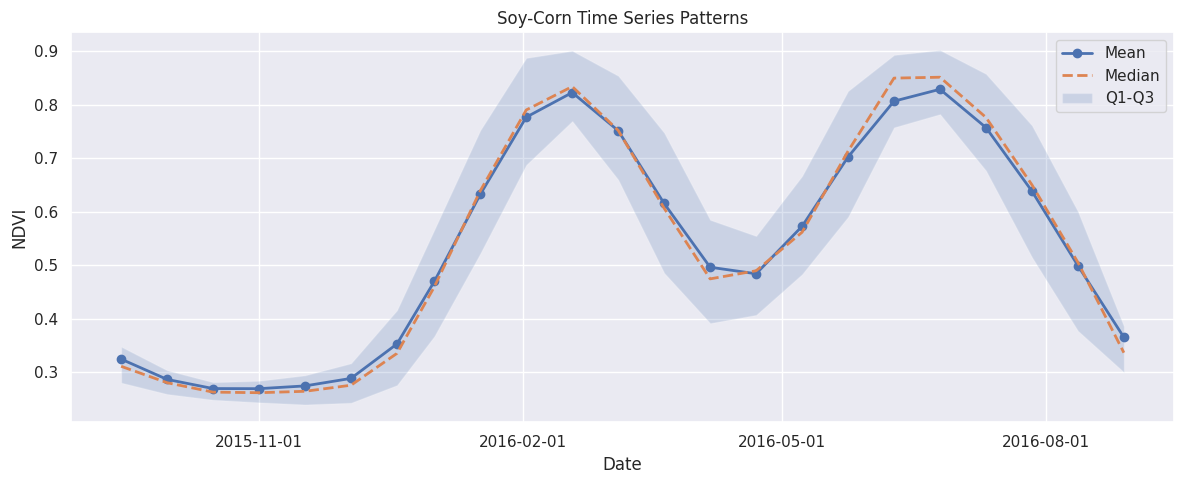

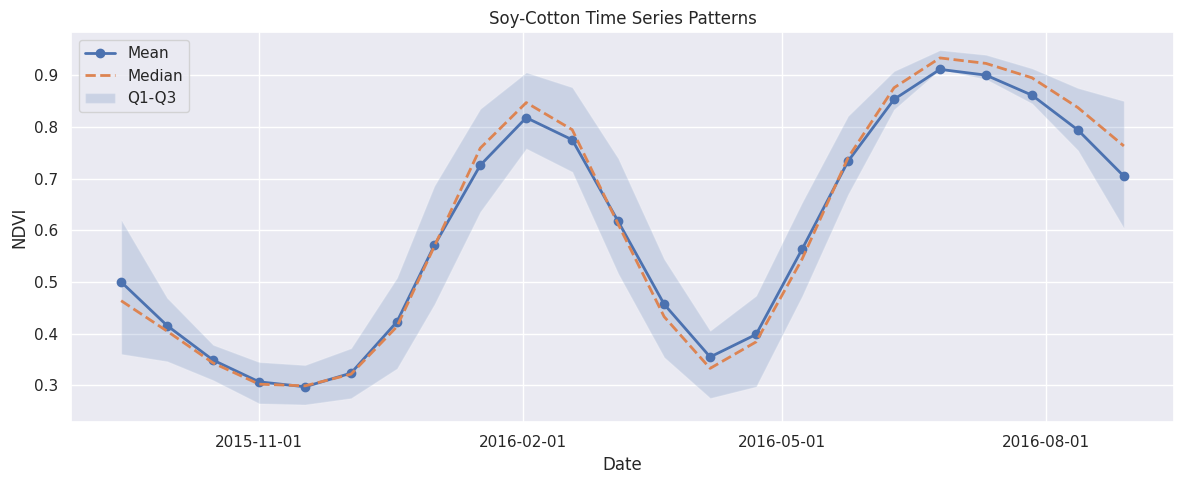

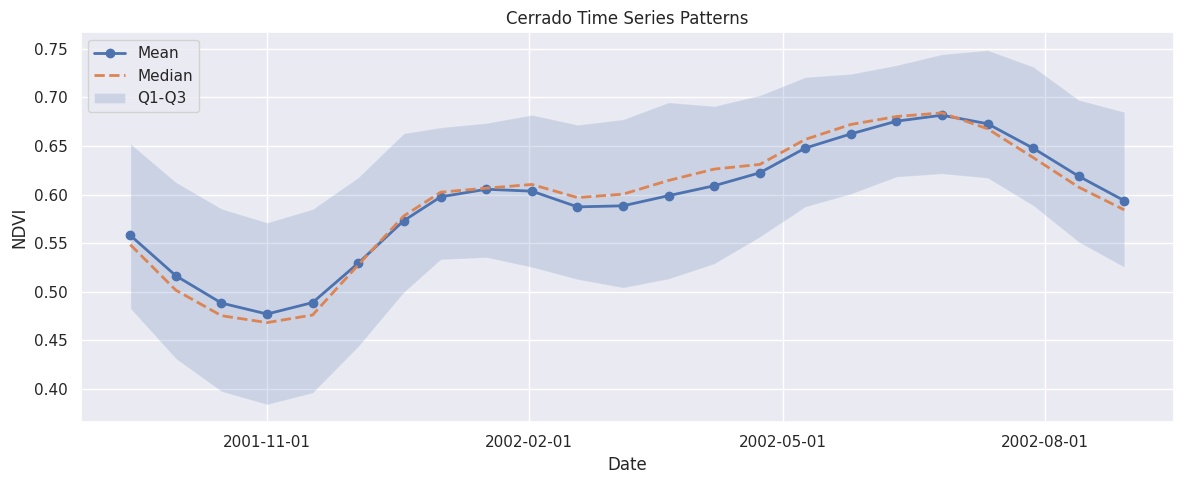

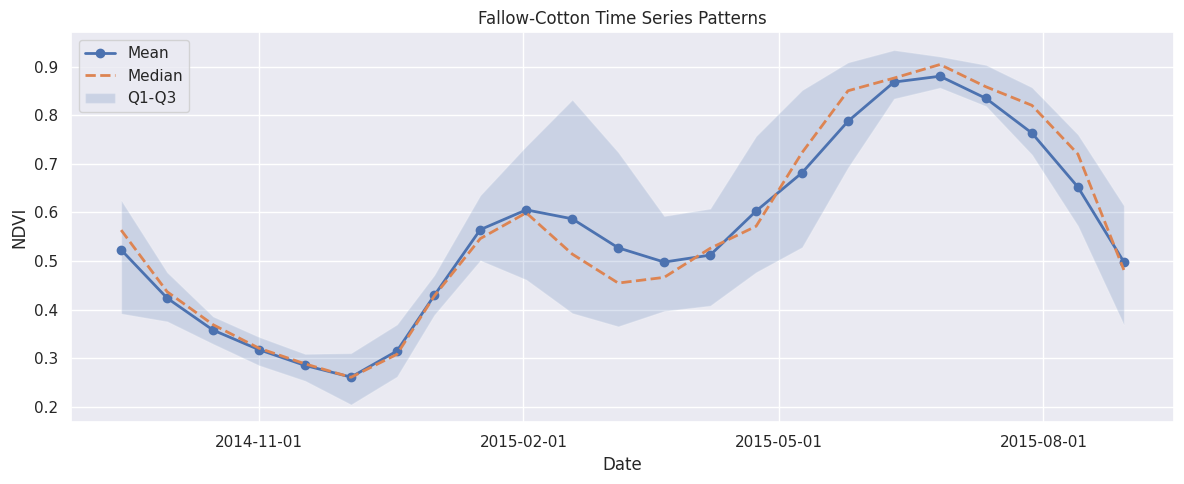

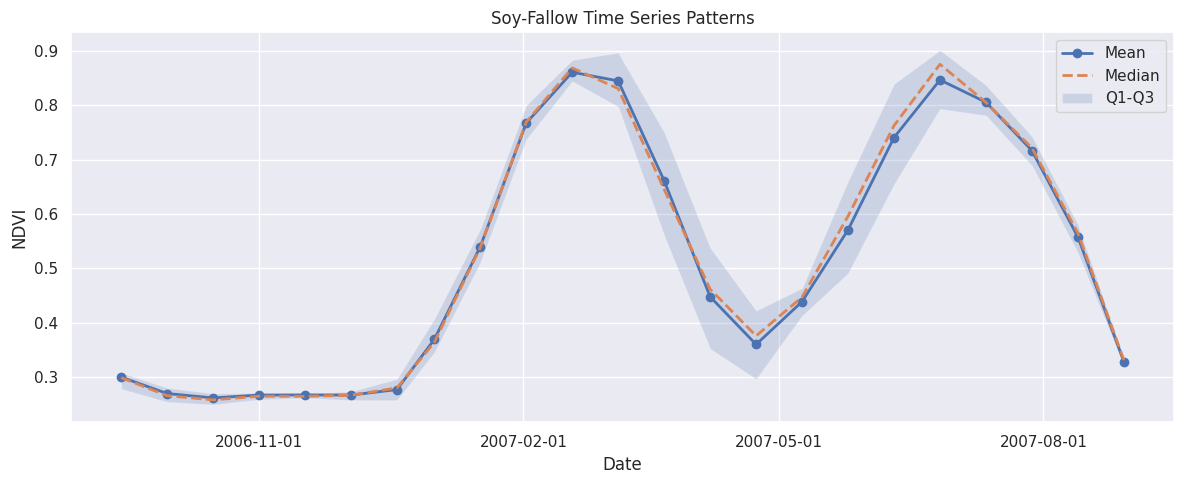

In [11]:
def plot_patterns(samples, band, step=3):

    labels = set(samples['label'])

    for label in labels:

        samples_label = (
            samples[samples['label'] == label]['time_series']
            .reset_index(drop=True)
        )

        all_values = []

        # Read all samples
        for row in range(len(samples_label)):

            df = pd.DataFrame(json.loads(samples_label[row]))

            # Keep only selected band
            values = df[band]

            all_values.append(values)

        # Create matrix:
        # rows = samples
        # cols = timesteps
        only_values = pd.concat(all_values, axis=1).T

        # Statistics
        mean_values = only_values.mean(axis=0)
        median_values = only_values.median(axis=0)

        q1 = only_values.quantile(0.25, axis=0)
        q3 = only_values.quantile(0.75, axis=0)

        # Dates
        indexes = pd.to_datetime(df["Index"])

        # Plot
        fig, ax = plt.subplots(figsize=(12, 5))

        # Mean curve
        ax.plot(
            indexes,
            mean_values,
            marker="o",
            linewidth=2,
            label="Mean"
        )

        # Median curve
        ax.plot(
            indexes,
            median_values,
            linestyle="--",
            linewidth=2,
            label="Median"
        )

        # Quartile interval
        ax.fill_between(
            indexes,
            q1,
            q3,
            alpha=0.2,
            label="Q1-Q3"
        )

        # Labels
        ax.set_title(f"{label} Time Series Patterns")
        ax.set_xlabel("Date")
        ax.set_ylabel(band)

        # Date spacing like your example
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=step))
        ax.xaxis.set_major_formatter(
            mdates.DateFormatter('%Y-%m-%d')
        )

        ax.legend()

        plt.tight_layout()
        plt.show()

plot_patterns(samples_smoothed, "NDVI")

In [12]:
def getAllClasses():
    return pd.DataFrame({
        "class_name": np.unique(samples['label']),
        "index": [0, 1, 2, 3, 4, 5, 6, 7, 8],
        "color": ["#FF7D66", "#5480FF", "#BDBDBD", "#698891", "#487D5D", "#AB5B96", "#45A2BF", "#92D199", "#92A7D1"]
    })

def getClass(index=-1, label=''):
    classes = getAllClasses()
    if index >= 0:
        result = classes[index == classes["index"]]
    if len(label):
        result = classes[label == classes["class_name"]]
    result = result.reset_index(drop = True)
    return result

classes = np.unique(samples['label'])

getAllClasses()

,class_name,index,color
0,Cerrado,0,#FF7D66
1,Fallow-Cotton,1,#5480FF
2,Forest,2,#BDBDBD
3,Pasture,3,#698891
4,Soy-Corn,4,#487D5D
5,Soy-Cotton,5,#AB5B96
6,Soy-Fallow,6,#45A2BF
7,Soy-Millet,7,#92D199
8,Soy-Sunflower,8,#92A7D1


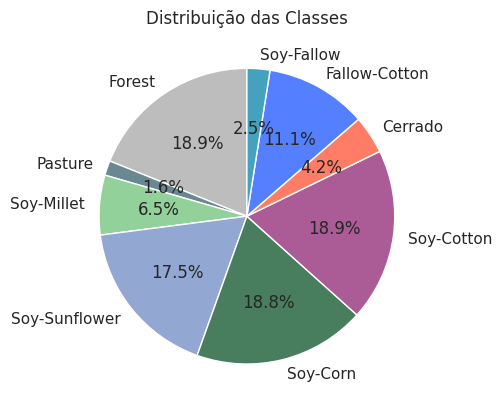

In [13]:
# Contar amostras por classe

def plot_distribution(samples):
    class_counts = pd.Series(list(samples['label'])).value_counts().sort_index()
    
    # Labels (nomes das classes)
    labels = [ str(getClass(label=label_)['class_name'][0]) for label_ in list(set(samples['label'])) ]
    
    colors = [ str(getClass(label=label_)['color'][0]) for label_ in list(set(samples['label'])) ]
    
    # Plotar gráfico de pizza
    plt.figure()
    plt.pie(class_counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
    plt.title('Distribuição das Classes')
    
    plt.show()

plot_distribution(samples=samples_smoothed)

## Formatando as séries temporais para a MLP

In [14]:
### Método para o flatten
def extract_features(ts_string):
    ts = json.loads(ts_string.replace('""', '"'))
    all_features = []
    for key_ in ts.keys():
        if key_ != "Index":
            all_features.append(np.array(ts[key_]))
    return np.concatenate(all_features)

random_sample = random.randint(0, (len(samples_smoothed) - 1))

original = samples_smoothed['time_series'][random_sample]
flatten = extract_features(original)

### Método para codificar as labels
def encode_label(label_):
    return int(getClass(label = label_)['index'].iloc[0])

label = samples_smoothed['label'][random_sample]
label_code = encode_label(label)

print(f"Original => ({label}): ", original, "\n")
print(f"Flatten => ({label_code}): ", flatten)
print()

Original => (Soy-Fallow):  {"Index": ["2006-09-14", "2006-09-30", "2006-10-16", "2006-11-01", "2006-11-17", "2006-12-03", "2006-12-19", "2007-01-01", "2007-01-17", "2007-02-02", "2007-02-18", "2007-03-06", "2007-03-22", "2007-04-07", "2007-04-23", "2007-05-09", "2007-05-25", "2007-06-10", "2007-06-26", "2007-07-12", "2007-07-28", "2007-08-13", "2007-08-29"], "NDVI": [0.30068333333333325, 0.26329523809523825, 0.25118095238095267, 0.25505714285714304, 0.2615952380952383, 0.2570285714285716, 0.2498714285714288, 0.32490000000000024, 0.4964095238095242, 0.7452047619047625, 0.809728571428572, 0.8101952380952387, 0.7295952380952386, 0.5783047619047623, 0.49403333333333377, 0.4990952380952385, 0.4781761904761909, 0.5844285714285719, 0.7424285714285719, 0.7579952380952388, 0.7104619047619051, 0.5694761904761908, 0.3187547619047622], "EVI": [0.16189047619047614, 0.14094047619047634, 0.1390404761904764, 0.14562380952380966, 0.14068571428571439, 0.12918571428571438, 0.10784761904761914, 0.12994761

## Separação de treino, teste e validação usando _Holdout_

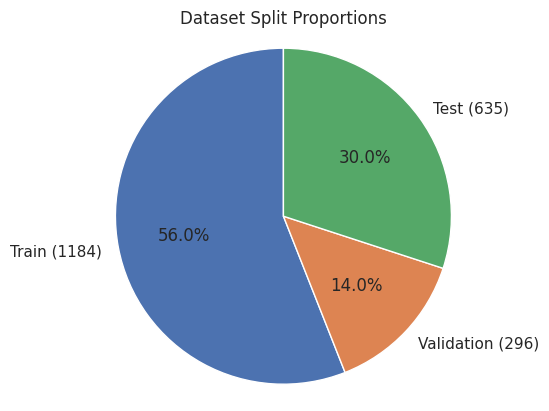

In [15]:
dataset = samples_smoothed.copy()

X = []
y = []

for _, row in dataset.iterrows():
    X.append(extract_features(row["time_series"]))
    y.append(encode_label(row["label"]))

X = np.array(X)
y = np.array(y)

# Example usage with your variables
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
std[std == 0] = 1
X_train = (X_train - mean) / std
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std

# Quantidade de amostras
train_size = len(X_train)
val_size = len(X_val)
test_size = len(X_test)

sizes = [train_size, val_size, test_size]
labels = [
    f"Train ({train_size})",
    f"Validation ({val_size})",
    f"Test ({test_size})"
]
plt.figure()
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Dataset Split Proportions")
plt.axis('equal')
plt.show()

## Arquitetura MLP

Usando regularização L2 para penalizar pesos grandes;

Usando early_stop;

Inicialização dos pesos com _He_;

Epoch 0 | Train Loss: 1.765738 | Val Loss: 1.196498

Early stopping at epoch 43
Best validation loss: 0.403392


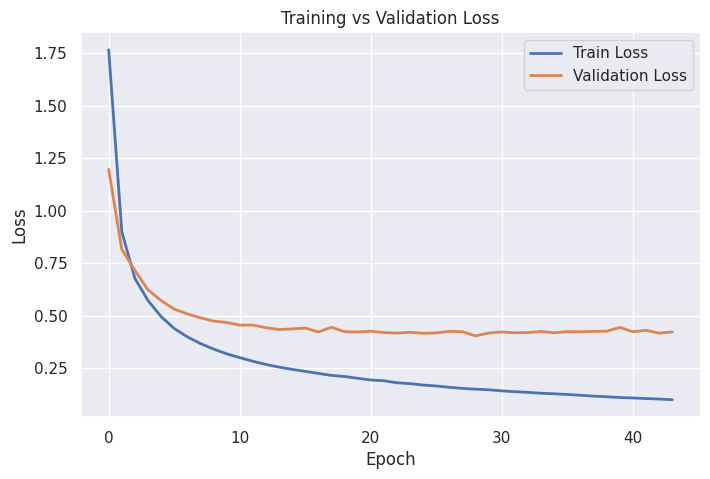

In [16]:
def tanh(x):
    return np.tanh(x)

def d_tanh(x):
    return 1 - np.tanh(x)**2

def relu(x):
    return np.maximum(0, x)

def d_relu(x):
    return (x > 0).astype(float)

def softmax(x):
    x = x - np.max(x)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=0, keepdims=True)

def d_softmax(x):
    s = softmax(x).reshape(-1, 1)
    return np.diagflat(s) - np.dot(s, s.T)

input_size = X.shape[1]

seed = 42

topology = [input_size, 32, 16, 9]

layers = [
    Layer(32, Neuron, relu, d_relu),
    Layer(16, Neuron, relu, d_relu),
    Layer(9, Neuron, softmax, d_softmax, multiclass=True)
]

nn = FFNeuralNetwork(topology, layers, method_init=He_, multiclass = True, lambda_l2=1e-4, rand_seed = seed)

nn.fit_with_validation(X_train, y_train, X_val, y_val, learning_rate=0.001, n_epochs=200, patience = 15)
nn.plot_train_val_loss()

In [19]:
def objective(trial):
    # ==================================================
    # HYPERPARAMETERS
    # ==================================================
    hidden1 = trial.suggest_int("hidden1", 16, 128)
    hidden2 = trial.suggest_int("hidden2", 8, 64)
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True)
    l2_lambda = trial.suggest_float("l2_lambda", 1e-6, 1e-2, log=True)
    activation_name = trial.suggest_categorical("activation", ["relu", "tanh"])
    init_name = trial.suggest_categorical("initializer", ["he", "xavier"])

    # ==================================================
    # ACTIVATION
    # ==================================================
    if activation_name == "relu":
        act = relu
        d_act = d_relu
    else:
        act = tanh
        d_act = d_tanh

    # ==================================================
    # INITIALIZATION
    # ==================================================
    if init_name == "he":
        initializer = He_
    else:
        initializer = Xavier

    # ==================================================
    # NETWORK
    # ==================================================
    input_size = X_train.shape[1]
    topology = [input_size, hidden1, hidden2, 9]
    layers = [
        Layer(hidden1, Neuron, act, d_act),
        Layer(hidden2, Neuron, act, d_act),
        Layer(9, Neuron, softmax, d_softmax, multiclass=True)
    ]
    nn = FFNeuralNetwork(topology, layers, multiclass=True, method_init=initializer, lambda_l2=l2_lambda)

    # ==================================================
    # TRAIN
    # ==================================================
    nn.fit_with_validation(X_train, y_train, X_val, y_val, learning_rate=learning_rate, n_epochs=100)

    # ==================================================
    # VALIDATION
    # ==================================================
    result = nn.test(X_test, y_test)
    metrics = result["metrics"]["accuracy"]
    return metrics

study = optuna.create_study(direction="maximize")

study.optimize(objective, n_trials=10)

print(study.best_trial)
print(study.best_params)
plot_optimization_history(study)
plot_param_importances(study)

[I 2026-05-11 18:06:05,053] A new study created in memory with name: no-name-3cc9f9fd-13d0-42c9-b355-6549f5bb973b


Epoch 0 | Train Loss: 1.041178 | Val Loss: 0.753405
Epoch 50 | Train Loss: 0.163564 | Val Loss: 0.348856


[I 2026-05-11 18:06:40,554] Trial 0 finished with value: 0.9102362204724409 and parameters: {'hidden1': 40, 'hidden2': 22, 'learning_rate': 0.0031352428627960346, 'l2_lambda': 0.007461567075321518, 'activation': 'tanh', 'initializer': 'xavier'}. Best is trial 0 with value: 0.9102362204724409.



Early stopping at epoch 92
Best validation loss: 0.340734
Epoch 0 | Train Loss: 1.494802 | Val Loss: 1.048310
Epoch 50 | Train Loss: 0.139583 | Val Loss: 0.348352


[I 2026-05-11 18:07:19,044] Trial 1 finished with value: 0.9086614173228347 and parameters: {'hidden1': 23, 'hidden2': 56, 'learning_rate': 0.0008412714613763389, 'l2_lambda': 1.0812081357219976e-05, 'activation': 'relu', 'initializer': 'xavier'}. Best is trial 0 with value: 0.9102362204724409.



Early stopping at epoch 77
Best validation loss: 0.344441
FrozenTrial(number=0, state=<TrialState.COMPLETE: 1>, values=[0.9102362204724409], datetime_start=datetime.datetime(2026, 5, 11, 18, 6, 5, 54712), datetime_complete=datetime.datetime(2026, 5, 11, 18, 6, 40, 554769), params={'hidden1': 40, 'hidden2': 22, 'learning_rate': 0.0031352428627960346, 'l2_lambda': 0.007461567075321518, 'activation': 'tanh', 'initializer': 'xavier'}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'hidden1': IntDistribution(high=128, log=False, low=16, step=1), 'hidden2': IntDistribution(high=64, log=False, low=8, step=1), 'learning_rate': FloatDistribution(high=0.01, log=True, low=1e-05, step=None), 'l2_lambda': FloatDistribution(high=0.01, log=True, low=1e-06, step=None), 'activation': CategoricalDistribution(choices=('relu', 'tanh')), 'initializer': CategoricalDistribution(choices=('he', 'xavier'))}, trial_id=0, value=None)
{'hidden1': 40, 'hidden2': 22, 'learning_rate': 0.00313

## Aplicação do conjunto de teste

In [ ]:
nn.test(X_test, y_test, threshold=0.6)
# predictions
y_probs, y_preds = nn.predict(X_test)

# plot confusion matrix
nn.plot_confusion_matrix(y_test, y_preds)

## Classificação de série temporal 2000 até agora:

Usando uma janela deslizante de 23 timestamps.

Usando como base de validação o WLTS.

In [ ]:
wlts_ = pd.read_csv("./samples/test_samples/[-57.9627287550, -13.4889087095]_wlts_ibge_mapbiomas.csv", sep = ";")
wtss_ = pd.read_csv("./samples/test_samples/[-57.9627287550, -13.4889087095]_wtss_mod13q1.csv")

def getAllClassesWLTS():
    return pd.DataFrame({
        "class_name": list(set(wlts_["class"])),
        "index": [0, 1, 2],
        "color": ["#9BD3E8", "#C9C285", "#C0F279"]
    })

def _set_NaN(value):
    if value != missing_value:
        return value
    else:
        return None

def interpolate_ts(ts_):
    for column in ts_.columns:
        if column != "Index":
            band_desc = get_band_description(column, bands_description)
            scale = band_desc['scale']
            missing_value = band_desc['nodata'] * scale
            ts_[column] = ts_[column].apply(_set_NaN).interpolate(
                method = 'linear',
                limit_direction = 'forward',
                order = 2
            )
    return ts_

class SGolay:
    def __init__(self, window_size: int, polynomial_order: int, mode: str = "interp"):
        self.mode = mode
        if (window_size % 2) != 0:
            self.window_size = window_size
        else:
            raise Exception("Window size must be odd number!")
        if window_size > polynomial_order:
            self.polynomial_order = polynomial_order
        else:
            raise Exception("Window size must be higher than the polynomial order!")

getAllClassesWLTS()

In [ ]:
wtss_ = interpolate_ts(wtss_)
wtss_ = sgolay.apply_ts(wtss_)
result, y_probs = classify_temporal_series(wtss_, nn, 23, getAllClasses())
result

In [ ]:
start_date_ = "2010-01-01"
end_date_ = "2015-12-31"

plot_temporal_classification(
    result,
    getAllClasses(),
    title="Temporal Classification",
    start_date=start_date_,
    end_date=end_date_
)
plot_real_trajectory(
    wtss_, wlts_,
    class_system=getAllClassesWLTS(),
    start_date=start_date_,
    end_date=end_date_
)